In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

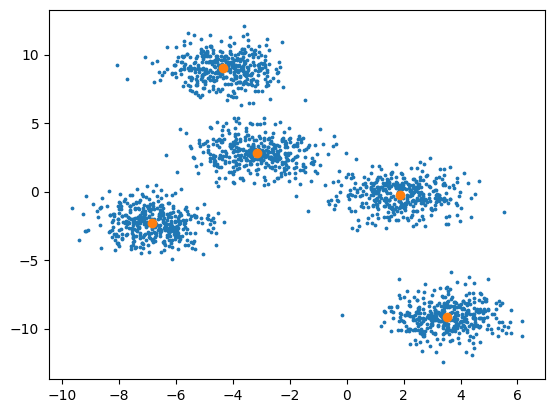

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=2000, random_state=51, n_features=2, centers=5)
k_means = KMeans(n_clusters=5, random_state=51)
y_pred = k_means.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], s=3)
plt.scatter(k_means.cluster_centers_[:, 0], k_means.cluster_centers_[:, 1])  

In [3]:
print(k_means.cluster_centers_)
k_means.predict(np.array([[4, 0]]))

[[-4.33223999  9.00219088]
 [ 3.53176483 -9.13601768]
 [ 1.86697246 -0.23181156]
 [-6.83157826 -2.27700663]
 [-3.15168831  2.8036569 ]]


array([2], dtype=int32)

In [4]:
k_means.inertia_

4050.6346688496537

In [5]:
from sklearn.cluster import MiniBatchKMeans

mbkm = MiniBatchKMeans(n_clusters=5, random_state=52)
mbkm.fit(X)

,n_clusters,5
,init,'k-means++'
,max_iter,100
,batch_size,1024
,verbose,0
,compute_labels,True
,random_state,52
,tol,0.0
,max_no_improvement,10
,init_size,None
,n_init,'auto'


### finding out optimal k

In [6]:
from sklearn.metrics import silhouette_score
silhouette_score(X, k_means.labels_)

0.714065415968422

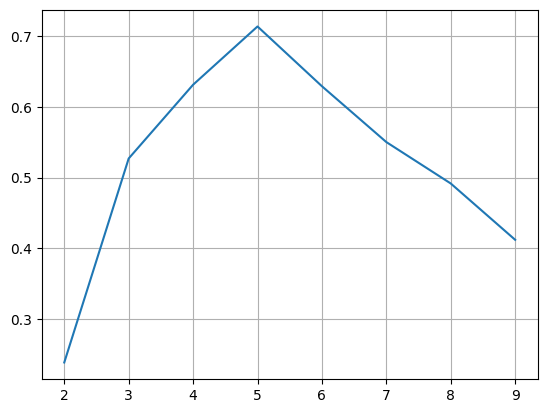

In [7]:
table = []
for k in range(2, 10):
    model = MiniBatchKMeans(n_clusters=k, random_state=52).fit(X)
    table.append([k, silhouette_score(X, model.labels_)])
  
table = np.array(table).reshape(-1, 2)

plt.plot(table[:, 0], table[:, 1])
plt.grid(True)

plt.show()

### image segmentation

In [8]:
import PIL 
image = np.asarray(PIL.Image.open('ladybug.png'))
image.shape

(533, 800, 3)

In [9]:
from sklearn.cluster import KMeans
X = image.reshape(-1, 3)
kmeans = KMeans(n_clusters=2, random_state=52).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)
segmented_img.shape

(533, 800, 3)

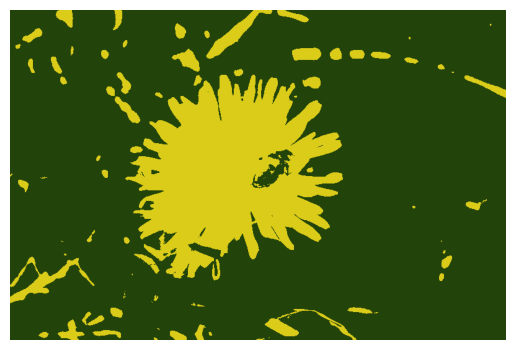

In [10]:
img = segmented_img
img_norm = img / 255.0   # масштабируем к диапазону [0, 1]

plt.imshow(img_norm)
plt.axis('off')
plt.show()

## semi supervized learning

In [11]:
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)
X_train, y_train = X[:1400], y[:1400]
X_test, y_test = X[1400:], y[1400:]

In [12]:
from sklearn.linear_model import LogisticRegression
n = 50

log_reg = LogisticRegression(random_state=52, max_iter=10000)
log_reg.fit(X_train[:n], y_train[:n])
log_reg.score(X_test, y_test)

0.7581863979848866

In [13]:
#50 represantative numbers
k = 50
kmeans = KMeans(n_clusters=k, random_state=52)
X_transformed = kmeans.fit_transform(X_train)
repres_id = X_transformed.argmin(axis=0)
X_repres = X_train[repres_id]
y_repres = y_train[repres_id]

In [14]:
log_reg = LogisticRegression(random_state=52, max_iter=10000)
log_reg.fit(X_repres, y_repres)
log_reg.score(X_test, y_test)

0.8312342569269522

In [15]:
#label propogation 
y_propogated = np.empty(len(X_train), dtype=np.int8)
for i in range(k):
    y_propogated[kmeans.labels_ == i] = y_repres[i]

In [16]:
log_reg = LogisticRegression(random_state=52, max_iter=10000)
log_reg.fit(X_train, y_propogated)
log_reg.score(X_test, y_test)

0.853904282115869

In [17]:
#removing outliers
X_dist = X_transformed[np.arange(X_transformed.shape[0]), kmeans.labels_]

for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    X_cluster = X_dist[in_cluster]
    threshold = np.median(X_cluster)
    X_cluster[X_cluster > threshold] = -1
    X_dist[in_cluster] = X_cluster
    
median_ids = (X_dist > -1)
X_reduced = X_train[median_ids]
y_reduced = y_propogated[median_ids]

In [18]:
log_reg = LogisticRegression(random_state=52, max_iter=10000)
log_reg.fit(X_reduced, y_reduced)
log_reg.score(X_test, y_test)

0.8740554156171285

In [19]:
#number of well classified images
np.mean(y_reduced == y_train[median_ids])

np.float64(0.9859353023909986)

## DBSCAN

In [1]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05, random_state=52)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)
dbscan.labels_[:7]

array([0, 1, 2, 1, 4, 3, 1])

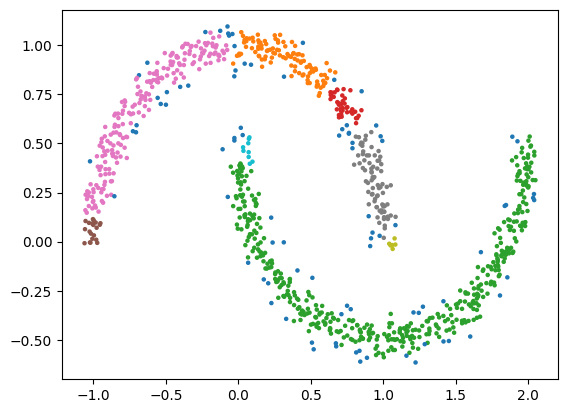

In [21]:
# bad epsilon
plt.scatter(X[:, 0], X[:, 1], s=5, c=dbscan.labels_, cmap='tab10')

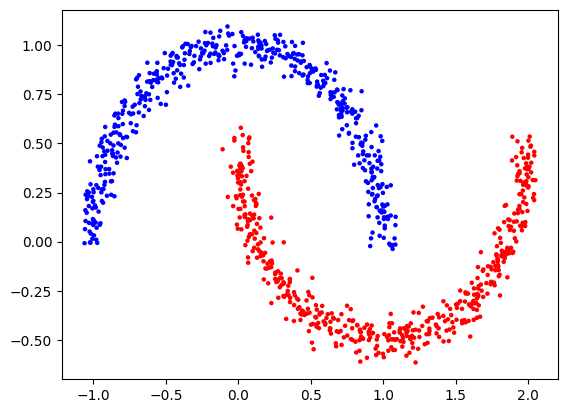

In [22]:
#good epsilon
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan.fit(X)
plt.scatter(X[:, 0], X[:, 1], s=5, c=dbscan.labels_, cmap='bwr')

In [ ]:
print(dbscan.core_sample_indices_[:10])
print(dbscan.components_)


[0 1 2 3 4 5 6 7 8 9]
[[ 0.40694671  0.95256504]
 [ 0.3171472  -0.28070892]
 [ 0.71338688  0.6359115 ]
 ...
 [ 0.00465885  0.34581229]
 [ 1.19057872 -0.41597817]
 [ 0.51559322 -0.41863945]]


In [24]:
from sklearn.neighbors import KNeighborsClassifier

knc = KNeighborsClassifier(n_neighbors=50)
knc.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

,n_neighbors,50
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [25]:
new = np.array([[-0.5, -0.25], [0, 0.8], [1.8, 0.46], [2, 1]])

print(knc.predict(new))
knc.predict_proba(new)

[0 0 1 1]


array([[0.6 , 0.4 ],
       [0.98, 0.02],
       [0.  , 1.  ],
       [0.  , 1.  ]])

In [26]:
#anomaly catching
dist, _ = knc.kneighbors(new, n_neighbors=1)
y_pred = knc.predict(new)
y_pred[dist.ravel() > 0.2] = -1
y_pred

array([-1,  0,  1, -1])

## Gausian Mixture

In [4]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=2000, random_state=51, n_features=2, centers=5)

In [5]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=5, n_init=10, random_state=52, covariance_type='spherical') #default = full
gm.fit(X)

print(gm.means_)
print(gm.weights_)

[[-3.14975887  2.80903253]
 [-4.3340682   9.00401344]
 [ 3.53176484 -9.13601782]
 [-6.83118912 -2.27643532]
 [ 1.86291913 -0.23158668]]
[0.2000413  0.1998185  0.19999999 0.20002359 0.20011662]


In [6]:
print(gm.converged_)
print(gm.n_iter_)

True
2


In [7]:
print(gm.predict([[-5, 10], [-3, 3], [-7, -2], [2, 0], [4,-10]]))
gm.predict_proba([[-5, 10], [-3, 3], [-7, -2], [2, 0], [4,-10], [3, -5]]).round(4)

[1 0 3 4 2]


array([[0.    , 1.    , 0.    , 0.    , 0.    ],
       [1.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 1.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 1.    ],
       [0.    , 0.    , 1.    , 0.    , 0.    ],
       [0.    , 0.    , 0.9091, 0.    , 0.0909]])

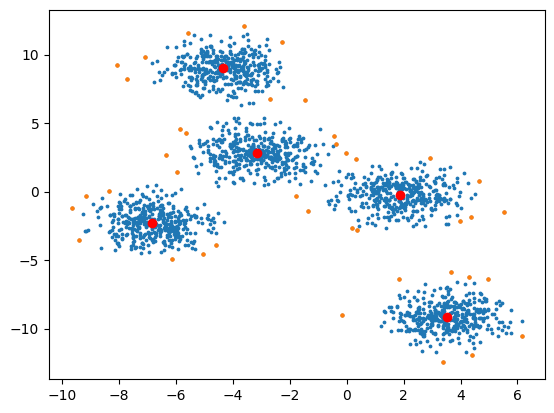

In [8]:
#anomaly detection
densities = gm.score_samples(X)
threshold = np.percentile(densities, 2)
anomalies = X[densities < threshold]

plt.scatter(X[:, 0], X[:, 1], s=3)
plt.scatter(anomalies[:, 0], anomalies[:, 1], s=5)
plt.scatter(gm.means_[:, 0], gm.means_[:, 1], c="red")

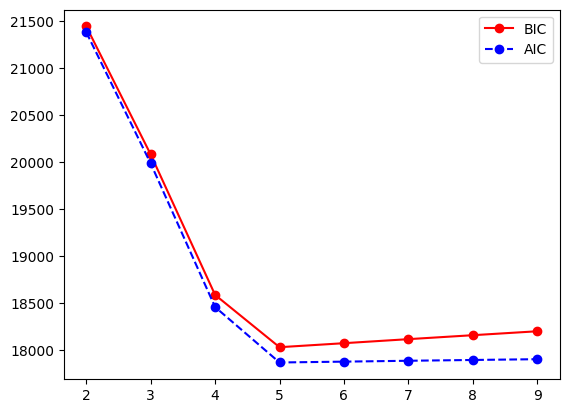

In [19]:
bic_aic=[]
for k in range(2, 10):
    gmt = GaussianMixture(n_components=k, n_init=10, random_state=52)
    gmt.fit(X)
    bic_aic.append([k, gmt.bic(X), gmt.aic(X)])
    
    
bic_aic = np.array(bic_aic)
plt.plot(bic_aic[:, 0], bic_aic[:, 1], "-or" , label="BIC")
plt.plot(bic_aic[:, 0], bic_aic[:, 2], "--ob" , label="AIC")
plt.legend()

plt.show()


In [21]:
# Bayesian Gausian mixture
from sklearn.mixture import BayesianGaussianMixture

bgm = BayesianGaussianMixture(n_components=10, n_init=10, max_iter=500, random_state=52)
bgm.fit(X)

bgm.weights_.round(3)

array([0.2  , 0.2  , 0.2  , 0.2  , 0.199, 0.   , 0.   , 0.   , 0.   ,
       0.   ])